PCA (Principal Component Analysis) on the digits dataset (64-pixel handwritten digit images). Finds the directions of maximum variance and projects data onto them — a linear, deterministic dimensionality reduction technique.

Shape: (1797, 64) (1797 images, 8x8=64 pixels each)


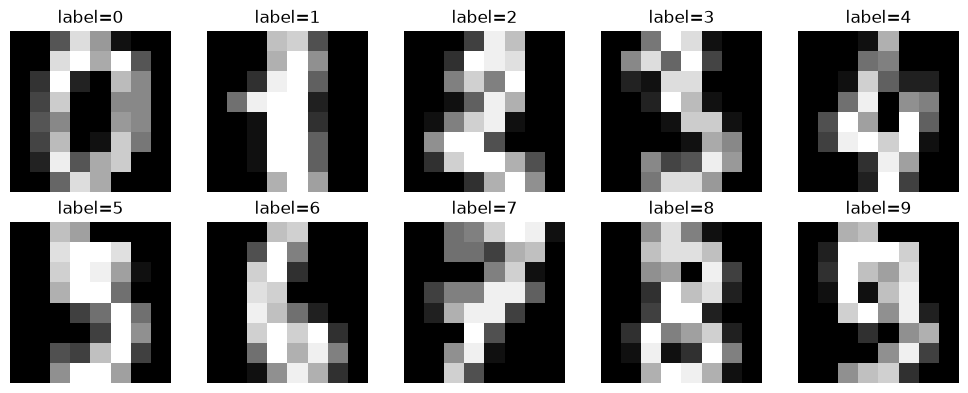

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X, y = digits.data, digits.target
print("Shape:", X.shape, "(1797 images, 8x8=64 pixels each)")

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"label={y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

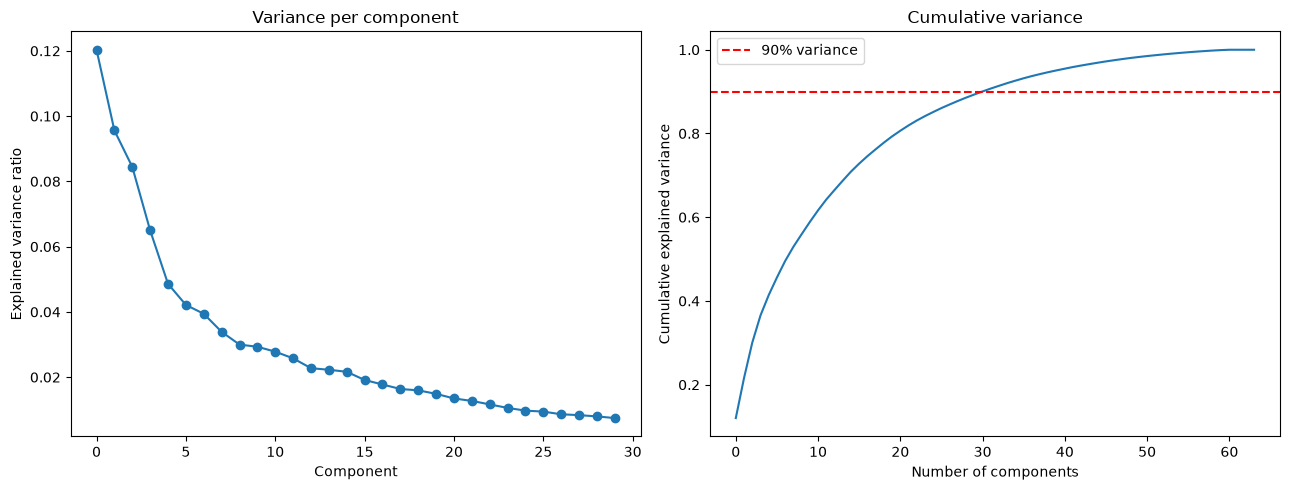

Components needed for 90% variance: 31 (out of 64 original dimensions)


In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA keeping all components first, to see how variance is distributed
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(explained[:30], 'o-')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Variance per component')

axes[1].plot(cumulative)
axes[1].axhline(0.90, color='red', linestyle='--', label='90% variance')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Cumulative variance')
axes[1].legend()
plt.tight_layout()
plt.show()

n_90 = int(np.searchsorted(cumulative, 0.90) + 1)
print(f"Components needed for 90% variance: {n_90} (out of {X.shape[1]} original dimensions)")

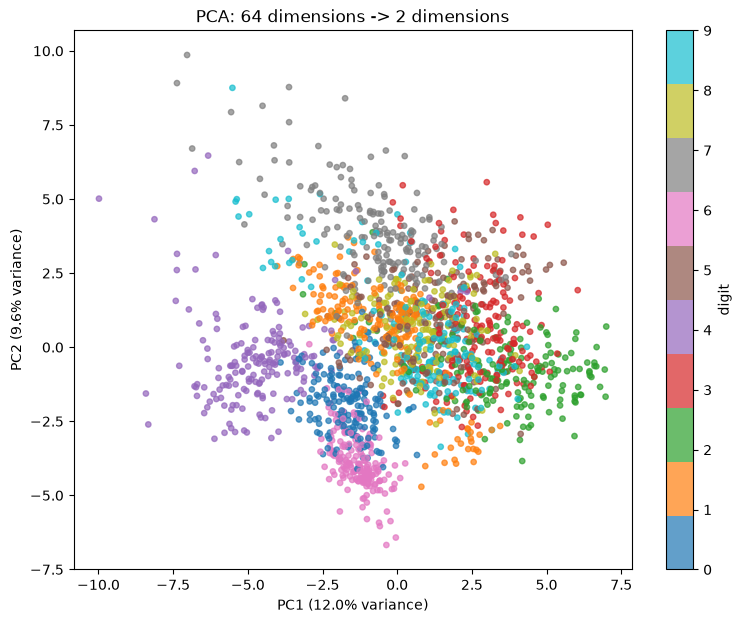

These 2 components only capture 21.6% of total variance
Some digit classes overlap heavily in just 2D -- PCA is linear and may not separate non-linear structure well.


In [3]:
# Reduce to 2D purely for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, label='digit')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA: 64 dimensions -> 2 dimensions')
plt.show()
print(f"These 2 components only capture {sum(pca_2d.explained_variance_ratio_)*100:.1f}% of total variance")
print("Some digit classes overlap heavily in just 2D -- PCA is linear and may not separate non-linear structure well.")

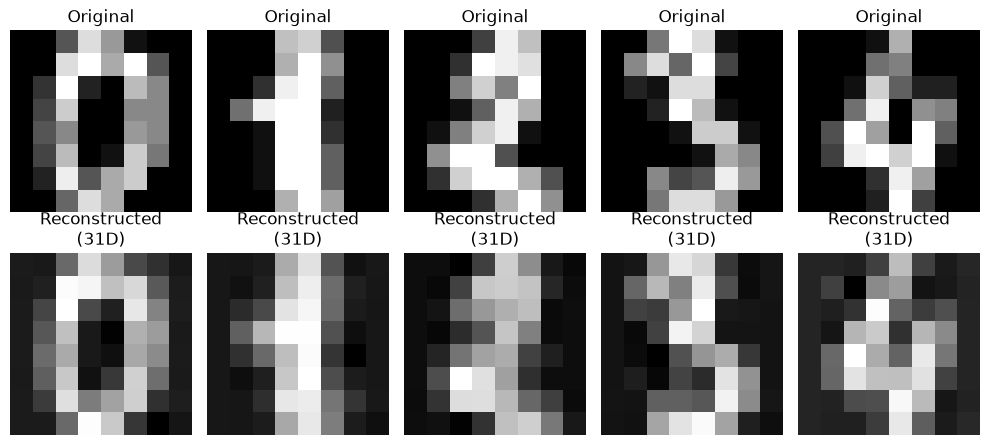

Reconstructed from only 31 components (vs original 64) -- some detail lost but digit is recognizable.


In [4]:
# Reconstruction: PCA is invertible (lossy), which is a key difference from t-SNE/UMAP
pca_recon = PCA(n_components=n_90)
X_reduced = pca_recon.fit_transform(X_scaled)
X_reconstructed = pca_recon.inverse_transform(X_reduced)
X_reconstructed_original_scale = scaler.inverse_transform(X_reconstructed)

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i in range(5):
    axes[0, i].imshow(X[i].reshape(8, 8), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')
    axes[1, i].imshow(X_reconstructed_original_scale[i].reshape(8, 8), cmap='gray')
    axes[1, i].set_title(f'Reconstructed\n({n_90}D)')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()
print(f"Reconstructed from only {n_90} components (vs original {X.shape[1]}) -- some detail lost but digit is recognizable.")